In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
tarundalal_dangerous_insects_dataset_path = kagglehub.dataset_download('tarundalal/dangerous-insects-dataset')

print('Data source import complete.')


# **Dangerous Insects Classification using CNN**

This notebook builds a Convolutional Neural Network (CNN) for classifying agricultural insect images into four categories.

# Import Required Libraries

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import os
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import classification_report
import numpy as np
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# Dataset Description

The dataset contains images of harmful agricultural insects and diseases.

Classes:
- Aphids
- Citrus Canker
- Spider Mites
- Thrips

Each image is assigned a numerical label that will be used during training.

In [ ]:
class_dict={"Aphids":0,"Citrus Canker":1,"Spider Mites":2,"Thrips":3}

base_path = "/kaggle/input/datasets/tarundalal/dangerous-insects-dataset/farm_insects"

trasform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.4642, 0.5204, 0.3377),(0.2419, 0.2262, 0.2446))
])

# Image Transformations


In [ ]:
imgs = []
for k,v in class_dict.items():
    d = os.path.join(base_path,k)
    for i in os.listdir(d):
        img = Image.open(os.path.join(d,i)).convert("RGB")
        imgs.append(trasform(img))

imgs = torch.stack(imgs)
imgs.shape

torch.Size([420, 3, 224, 224])

# Data Analysis


In [ ]:
m = imgs.mean(dim=[0,2,3])
std = imgs.std(dim=[0,2,3])
m,std

(tensor([-7.0267e-05, -1.5375e-04,  1.2499e-04]),
 tensor([0.9999, 1.0001, 1.0000]))

## Loading Images


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2659454..2.178611].


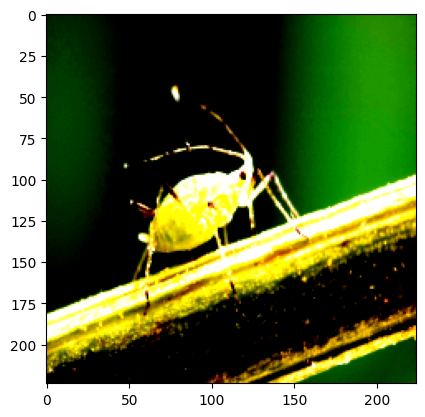

In [ ]:
img = Image.open("/kaggle/input/datasets/tarundalal/dangerous-insects-dataset/farm_insects/Aphids/Image_1.jpeg")
plt.imshow(trasform(img).permute(1,2,0))

In [ ]:
img_paths=[]
samples=[]
for k,v in class_dict.items():
    d = os.path.join(base_path,k)
    for i in os.listdir(d):
        samples.append((os.path.join(d,i),v))
samples[0]

# len(img_paths),img_paths[200]

('/kaggle/input/datasets/tarundalal/dangerous-insects-dataset/farm_insects/Aphids/Image_22.jpg',
 0)

## Creating a Custom PyTorch Dataset

A custom Dataset class is implemented to:

- Read images from disk
- Apply transformations
- Return image-label pairs

This class follows the PyTorch Dataset interface and can be used with DataLoader.

In [ ]:
class Data(Dataset):
    def __init__(self,base_path,class_dict,transform):
        self.root_dir = base_path
        self.cls = class_dict
        self.transform = transform

        self.samples = []
        self.img_paths = []
        for k,v in self.cls.items():
            d = os.path.join(self.root_dir,k)
            for i in os.listdir(d):
                self.samples.append((os.path.join(d,i),v))
    def __len__(self):
        return len(self.samples)

    def __getitem__(self,idx):
        img,l=self.samples[idx]
        img = Image.open(img).convert("RGB")
        if self.transform:
            img=self.transform(img)
        return img,l

In [ ]:
full_data = Data(
    base_path = base_path,
    class_dict = class_dict,
    transform = trasform
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0579047..2.4992626].


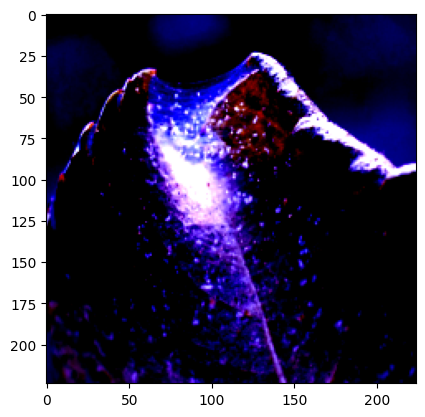

In [ ]:
img,l = full_data[200]
plt.imshow(img.permute(1,2,0))

# Train-Test Split

In [ ]:
train_size = int(0.8*len(full_data))
test_size = int(len(full_data)-train_size)

train_data, val_data = random_split(
    full_data,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

## Data Loading with DataLoader

DataLoader is responsible for:

- Creating mini-batches
- Shuffling training samples
- Efficient data loading during training

Batch Size = 32

In [ ]:
train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size = 32,
    shuffle=False
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.300619..2.707686].


(<matplotlib.image.AxesImage at 0x7dda77126510>, tensor(1))

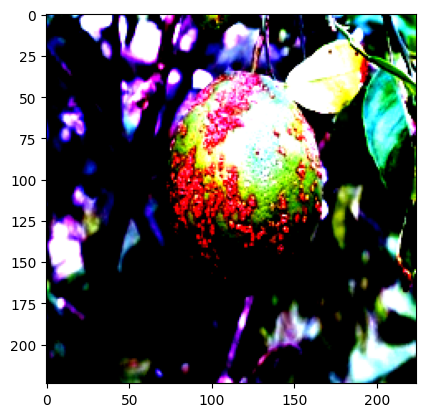

In [ ]:
img,label = next(iter(train_loader))

plt.imshow(img[0].permute(1,2,0)), label[0]

# CNN Architecture

- BatchNorm = Training stable
- Dropout = Reduces Overfitting
- Fully Connected Layers = Linear(4096,1000)
- Loss Function
- Optimizer
- Backpropagation = train_loss.backward()
- Weights update = optimizer.step()

In [ ]:
class NetNormDrop(nn.Module):
    def __init__(self, n_chans1):
        super().__init__()
        self.nchans=n_chans1
        self.conv1=nn.Conv2d(3,self.nchans,kernel_size=3,padding=1,stride=2)
        self.conv1_batch = nn.BatchNorm2d(num_features=self.nchans)
        self.conv1_drop=nn.Dropout2d(p=0.2)
        self.conv2=nn.Conv2d(self.nchans,self.nchans*2, kernel_size=3,padding=1,stride=2)
        self.conv2_batch = nn.BatchNorm2d(num_features=self.nchans*2)
        self.conv2_drop=nn.Dropout2d(p=0.2)
        self.conv3 = nn.Conv2d(self.nchans*2,self.nchans*4,kernel_size=3,padding=1,stride=2)
        self.conv3_batch = nn.BatchNorm2d(num_features=self.nchans*4)
        self.conv3_drop=nn.Dropout(p=0.2)
        self.conv4=nn.Conv2d(self.nchans*4,self.nchans*8, kernel_size=3, padding=1,stride=2)
        self.conv4_batch = nn.BatchNorm2d(num_features=self.nchans*8)
        self.conv4_drop=nn.Dropout(p=0.2)
        self.gap=nn.AdaptiveAvgPool2d((4,4))
        self.fc1=nn.Linear(4096,1000)
        self.fc2=nn.Linear(1000,100)
        self.fc3=nn.Linear(100,4)
    def forward(self,x):
        out=self.conv1_drop(F.relu(self.conv1_batch(self.conv1(x))))
        out=self.conv2_drop(F.relu(self.conv2_batch(self.conv2(out))))
        out=self.conv3_drop(F.relu(self.conv3_batch(self.conv3(out))))
        out=self.conv4_drop(F.relu(self.conv4_batch(self.conv4(out))))
        out=self.gap(out)
        out=torch.flatten(out,1)
        out=torch.relu(self.fc1(out))
        out=torch.relu(self.fc2(out))
        out=self.fc3(out)
        return out

## Training Loop

In [ ]:
def training_loop(n_epochs,optimizer,loss_fn,train_loader, model):
    train_history=[]
    test_history=[]
    model.to(device)
    model.train()
    for i in range(n_epochs):
        t_loss=0
        for img,l in train_loader:
            img,l=img.to(device),l.to(device)
            preds = model(img)
            train_loss = loss_fn(preds,l)

            optimizer.zero_grad()
            train_loss.backward()
            optimizer.step()

            t_loss+=train_loss.item()
        avg_train_loss = t_loss / len(train_loader)
        train_history.append(avg_train_loss)

        model.eval()
        tst_loss=0
        with torch.no_grad():
            for img,l in val_loader:
                img,l=img.to(device),l.to(device)
                preds = model(img)
                test_loss = loss_fn(preds,l)
                tst_loss+=test_loss.item()
        avg_val_loss =tst_loss/len(val_loader)
        test_history.append(avg_val_loss)

        print(f"{i} Epoch ,Avg train loss:{avg_train_loss:.4f}, Avg val loss: {avg_val_loss:.4f}")
    return train_history, test_history

In [ ]:
# def val_preds(model, lsf, val_loader):
#     model.eval()
#     tst_loss=0
#     test_history=[]
#     with torch.no_grad():
#         for img,l in val_loader:
#             img,l=img.to(device),l.to(device)
#             preds = model(img)
#             test_loss = lsf(preds,l)
#             tst_loss+=test_loss.item()
#         avg_loss+=tst_loss/len(val_loader)
#         test_history.append(avg_loss)
#     return test_history

## Dropout and Optimizer

In [ ]:
model = NetNormDrop(32)

opt = optim.Adam(model.parameters(), lr=1e-04)

loss_fn = nn.CrossEntropyLoss()

train_hist, test_hist = training_loop(
    model=model,
    n_epochs=20,
    optimizer=opt,
    loss_fn=loss_fn,
    train_loader = train_loader
)

0 Epoch ,Avg train loss:1.3652, Avg val loss: 1.3770
1 Epoch ,Avg train loss:1.3714, Avg val loss: 1.3677
2 Epoch ,Avg train loss:1.3436, Avg val loss: 1.3376
3 Epoch ,Avg train loss:1.2988, Avg val loss: 1.3123
4 Epoch ,Avg train loss:1.2785, Avg val loss: 1.3191
5 Epoch ,Avg train loss:1.2348, Avg val loss: 1.2814
6 Epoch ,Avg train loss:1.2100, Avg val loss: 1.3036
7 Epoch ,Avg train loss:1.1765, Avg val loss: 1.2408
8 Epoch ,Avg train loss:1.1243, Avg val loss: 1.2377
9 Epoch ,Avg train loss:1.1440, Avg val loss: 1.2601
10 Epoch ,Avg train loss:1.0881, Avg val loss: 1.1973
11 Epoch ,Avg train loss:1.0362, Avg val loss: 1.2249
12 Epoch ,Avg train loss:0.9938, Avg val loss: 1.2594
13 Epoch ,Avg train loss:0.9401, Avg val loss: 1.2732
14 Epoch ,Avg train loss:0.9380, Avg val loss: 1.2623
15 Epoch ,Avg train loss:0.8700, Avg val loss: 1.2099
16 Epoch ,Avg train loss:0.8315, Avg val loss: 1.2325
17 Epoch ,Avg train loss:0.8090, Avg val loss: 1.3933
18 Epoch ,Avg train loss:0.8298, Avg v

# Predictions

In [ ]:
def model_preds(model, val_loader):
    model.eval()
    preds=[]
    tru=[]
    for img,l in val_loader:
        img,l=img.to(device),l.to(device)
        p=model(img)
        _,out=torch.max(p,1)
        preds.extend(out.cpu().numpy())
        tru.extend(l.cpu().numpy())
    return preds,tru

# Training Progress Visualization Graph

<Axes: >

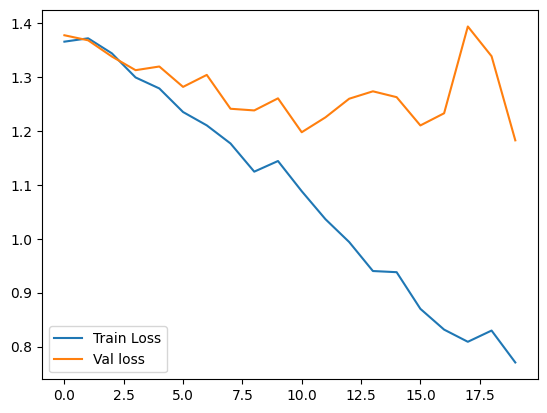

In [ ]:
epochs=[i for i in range(20)]
sns.lineplot(x=epochs,y=train_hist,label="Train Loss")
sns.lineplot(x=epochs,y=test_hist,label="Val loss")

# Classification Report

In [ ]:
y_pred,y_true=model_preds(
    model=model,
    val_loader=val_loader
)

len(y_pred)==len(y_true)
clr = classification_report(y_true,y_pred)
print(clr)

              precision    recall  f1-score   support

           0       0.38      0.25      0.30        20
           1       0.42      0.65      0.51        17
           2       0.59      0.59      0.59        22
           3       0.61      0.56      0.58        25

    accuracy                           0.51        84
   macro avg       0.50      0.51      0.50        84
weighted avg       0.51      0.51      0.50        84



# Conclusion

A CNN-based image classification model was trained to identify harmful agricultural insects.

The notebook demonstrates:

- Data preprocessing
- CNN implementation
- Training and validation
- Performance evaluation using classification metrics

This serves as a complete deep learning pipeline for image classification using PyTorch.